In [1]:
import pandas as pd
df = pd.read_parquet('main_df_edited.parquet')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,country_full,arrival_date_month_num
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,Portugal,6
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,Portugal,6
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,United Kingdom,6
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,United Kingdom,6
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03,United Kingdom,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118893,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,0,Transient,96.14,0,0,Check-Out,2017-09-06,Belgium,7
118894,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,0,Transient,225.43,0,2,Check-Out,2017-09-07,France,7
118895,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,157.71,0,4,Check-Out,2017-09-07,Germany,7
118896,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,0,Transient,104.40,0,0,Check-Out,2017-09-07,United Kingdom,7


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00:00:01:00:01


In [4]:

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, accuracy_score
df = df.drop_duplicates()
X = df.drop(columns=['is_canceled']).copy()
y = df.is_canceled
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

cat_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status',
    'country_full'
]
model = CatBoostClassifier(cat_features=cat_cols)
model.fit(X_train, y_train)
f1_score(model.predict(X_test), y_test)

Learning rate set to 0.062878
0:	learn: 0.4331615	total: 250ms	remaining: 4m 10s
1:	learn: 0.2758544	total: 424ms	remaining: 3m 31s
2:	learn: 0.1712391	total: 604ms	remaining: 3m 20s
3:	learn: 0.1073130	total: 758ms	remaining: 3m 8s
4:	learn: 0.0686929	total: 947ms	remaining: 3m 8s
5:	learn: 0.0448886	total: 1.11s	remaining: 3m 3s
6:	learn: 0.0292132	total: 1.26s	remaining: 2m 59s
7:	learn: 0.0187716	total: 1.35s	remaining: 2m 48s
8:	learn: 0.0129948	total: 1.51s	remaining: 2m 46s
9:	learn: 0.0091759	total: 1.63s	remaining: 2m 41s
10:	learn: 0.0065158	total: 1.78s	remaining: 2m 40s
11:	learn: 0.0047615	total: 1.92s	remaining: 2m 37s
12:	learn: 0.0033841	total: 2.05s	remaining: 2m 35s
13:	learn: 0.0025705	total: 2.17s	remaining: 2m 32s
14:	learn: 0.0019833	total: 2.28s	remaining: 2m 29s
15:	learn: 0.0015506	total: 2.38s	remaining: 2m 26s
16:	learn: 0.0012540	total: 2.49s	remaining: 2m 23s
17:	learn: 0.0010133	total: 2.61s	remaining: 2m 22s
18:	learn: 0.0010104	total: 2.75s	remaining: 2m

1.0

In [5]:
import shap
shap.initjs()

In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
shap.plots.force(shap_values[:10])

TypeError: Object of type Timestamp is not JSON serializable

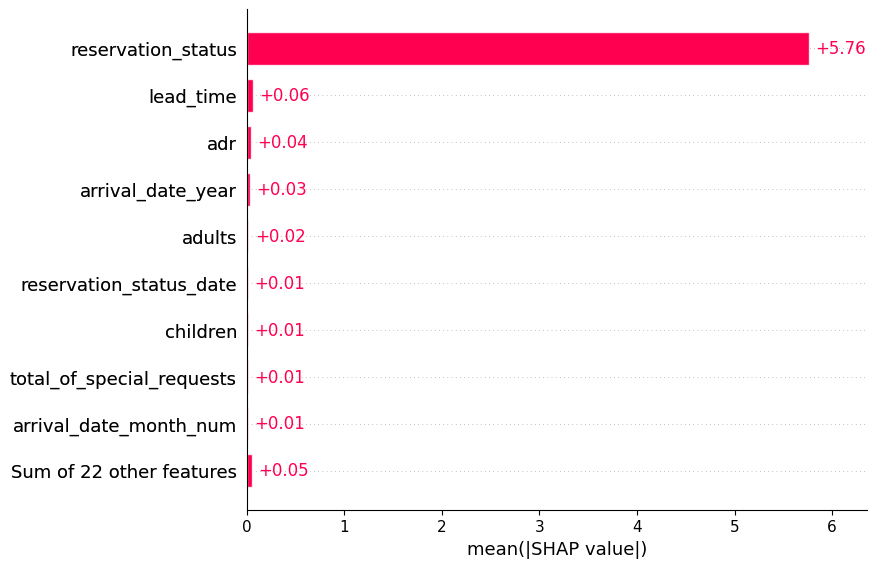

In [7]:
shap.plots.bar(shap_values)

In [9]:
df_new = df.drop(columns=['reservation_status'])
X = df_new.drop(columns=['is_canceled']).copy()
y = df_new.is_canceled
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

cat_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'deposit_type', 'customer_type',
    'country_full'
]
model = CatBoostClassifier(cat_features=cat_cols)
model.fit(X_train, y_train)
f1_score(model.predict(X_test), y_test)

Learning rate set to 0.062878
0:	learn: 0.6533920	total: 230ms	remaining: 3m 50s
1:	learn: 0.6279112	total: 398ms	remaining: 3m 18s
2:	learn: 0.6061721	total: 569ms	remaining: 3m 9s
3:	learn: 0.5811988	total: 768ms	remaining: 3m 11s
4:	learn: 0.5653160	total: 1.01s	remaining: 3m 20s
5:	learn: 0.5516485	total: 1.26s	remaining: 3m 29s
6:	learn: 0.5392644	total: 1.56s	remaining: 3m 41s
7:	learn: 0.5191002	total: 1.82s	remaining: 3m 46s
8:	learn: 0.5016136	total: 2.13s	remaining: 3m 54s
9:	learn: 0.4904530	total: 2.39s	remaining: 3m 57s
10:	learn: 0.4798748	total: 2.68s	remaining: 4m 1s
11:	learn: 0.4698828	total: 2.92s	remaining: 4m
12:	learn: 0.4626689	total: 3.21s	remaining: 4m 3s
13:	learn: 0.4518016	total: 3.44s	remaining: 4m 2s
14:	learn: 0.4459725	total: 3.7s	remaining: 4m 3s
15:	learn: 0.4411636	total: 3.89s	remaining: 3m 59s
16:	learn: 0.4332397	total: 4.06s	remaining: 3m 54s
17:	learn: 0.4281896	total: 4.23s	remaining: 3m 50s
18:	learn: 0.4198358	total: 4.39s	remaining: 3m 46s
19

0.9323156358738355

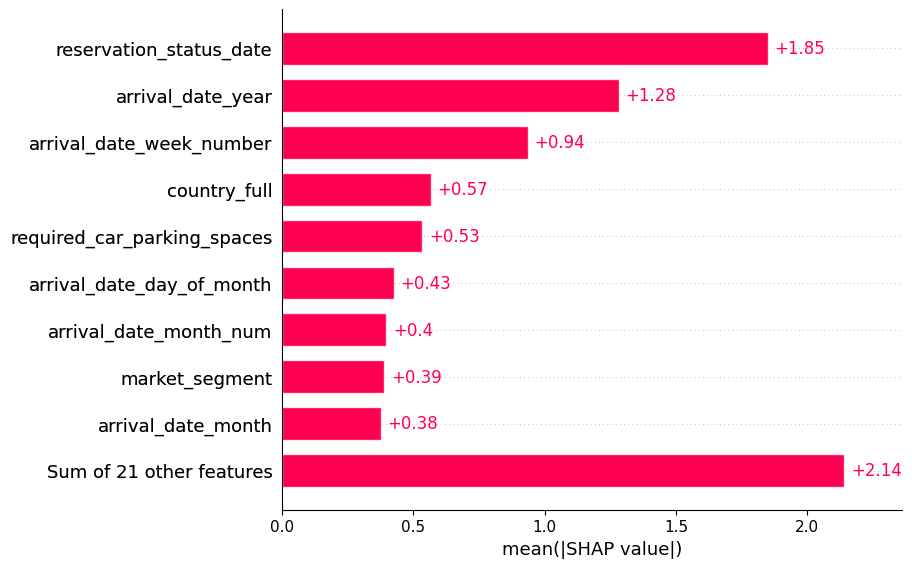

In [10]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
shap.plots.bar(shap_values)

In [11]:
df_new = df.drop(columns=['reservation_status', 'reservation_status_date'])
X = df_new.drop(columns=['is_canceled']).copy()
y = df_new.is_canceled
X_train,  X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

cat_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'deposit_type', 'customer_type',
    'country_full'
]
model = CatBoostClassifier(cat_features=cat_cols)
model.fit(X_train, y_train)
f1_score(model.predict(X_test), y_test)

Learning rate set to 0.062878
0:	learn: 0.6551747	total: 204ms	remaining: 3m 23s
1:	learn: 0.6220627	total: 380ms	remaining: 3m 9s
2:	learn: 0.6010723	total: 541ms	remaining: 2m 59s
3:	learn: 0.5815879	total: 722ms	remaining: 2m 59s
4:	learn: 0.5560170	total: 890ms	remaining: 2m 57s
5:	learn: 0.5363014	total: 1.03s	remaining: 2m 51s
6:	learn: 0.5152957	total: 1.19s	remaining: 2m 48s
7:	learn: 0.5014207	total: 1.35s	remaining: 2m 47s
8:	learn: 0.4903161	total: 1.5s	remaining: 2m 45s
9:	learn: 0.4794442	total: 1.66s	remaining: 2m 44s
10:	learn: 0.4703384	total: 1.85s	remaining: 2m 46s
11:	learn: 0.4629519	total: 1.98s	remaining: 2m 43s
12:	learn: 0.4570967	total: 2.14s	remaining: 2m 42s
13:	learn: 0.4522162	total: 2.3s	remaining: 2m 42s
14:	learn: 0.4479918	total: 2.46s	remaining: 2m 41s
15:	learn: 0.4435815	total: 2.62s	remaining: 2m 41s
16:	learn: 0.4402047	total: 2.79s	remaining: 2m 41s
17:	learn: 0.4375840	total: 2.94s	remaining: 2m 40s
18:	learn: 0.4347667	total: 3.11s	remaining: 2m

0.7056825899932081

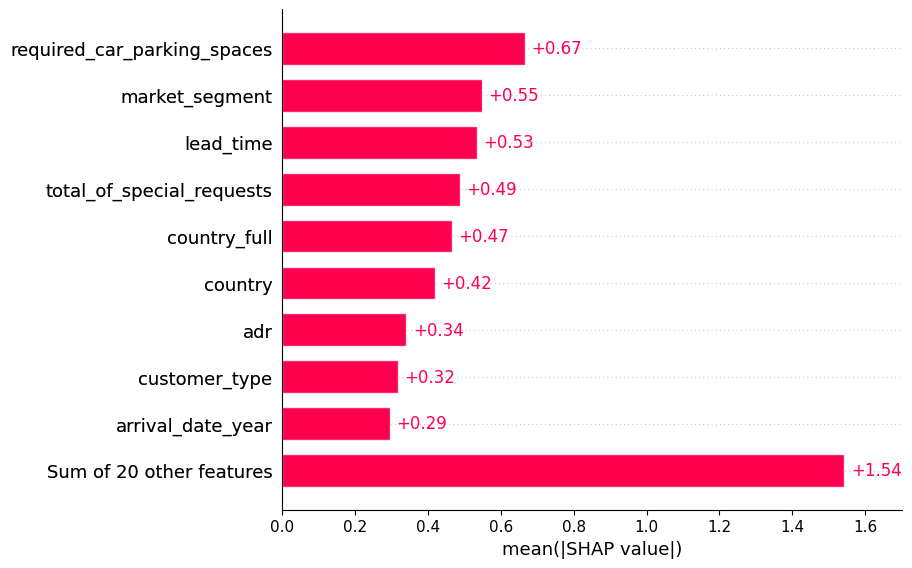

In [12]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)
shap.plots.bar(shap_values)

# Тест mlutils

In [7]:
from ml_utils import load_results, run_experiment
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
cat_cols = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel', 'reserved_room_type',
    'assigned_room_type', 'deposit_type', 'customer_type',
    'country_full'
]

model = Pipeline([('catboost', CatBoostClassifier(cat_features=cat_cols))])
run_experiment(model, 'baseline', cv=2)

RuntimeError: Cannot clone object CatBoostClassifier(cat_features=['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'country_full']), as the constructor either does not set or modifies parameter cat_features